# Propósito:

Extrair os dados da camada BRONZE e...
- Fazer a análise preliminiar (contagem de valores ausentes e extração de estatísticas bases)
- Limpeza e padronização dos dados
- Separação dos dados em "treino" e "teste"
- Salvamento das etapas acima na camada SILVER

# 1. Importação de Bibliotecas e Carregamento dos Dados

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## 1.1. Configuração visual para os gráficos

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1.2. Carregamwnto do Dataset

In [3]:
BRONZE_PATH = '../data/bronze/dataset.csv'

df_bronze = pd.read_csv(BRONZE_PATH)
df_bronze.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# 2. Visualização Base dos Dados

Nesta etapa, verificamos a estrutura geral do dataset, os tipos de dados de cada atributo e a distribuição dos valores.

In [4]:
print("=== Informações do Dataset ===")
df_bronze.info()

=== Informações do Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usag

In [ ]:
print("\n=== Estatísticas Descritivas ===")
display(df_bronze.describe(include='all'))


=== Estatísticas Descritivas ===


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


## 2.2. Verificação de Value Counts para cada atributo:

In [7]:
print("\n=== Contagem de Valores para Atributos Categóricos ===")
categorical_cols = df_bronze.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    print(f"\nVariável: {col}")
    print(df_bronze[col].value_counts())


=== Contagem de Valores para Atributos Categóricos ===

Variável: gender
gender
male      615
female    585
Name: count, dtype: int64

Variável: platform_usage
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Variável: social_interaction_level
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64


In [170]:
df_bronze['platform_usage'].value_counts()

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

# 3. Análise de Dados Faltantes

Ferramentas de AutoML geralmente lidam com dados faltantes, mas é uma boa prática documentar e tratar isso na camada Silver se a ausência for severa.

In [8]:
missing_data = df_bronze.isna().sum()
missing_perc = (missing_data / len(df_bronze)) * 100

missing_df = pd.DataFrame({
    'Valores Faltantes': missing_data, 
    'Percentual (%)': missing_perc
})

Análise de valores nulos:

In [9]:
print("=== Análise de Dados Faltantes ===")
display(missing_df[missing_df['Valores Faltantes'] > 0])

# Se o DataFrame estiver vazio, significa que não há dados faltantes.
if missing_data.sum() == 0:
    print("Excelente: O dataset não possui valores faltantes!")

=== Análise de Dados Faltantes ===


,Valores Faltantes,Percentual (%)


Excelente: O dataset não possui valores faltantes!


# 4. Limpeza e Padronização dos Dados (Encoding):

O FLAML e o MLJAR possuem otimizações internas robustas para lidar nativamente com colunas do tipo category do Pandas.

In [10]:
df_silver = df_bronze.copy()

### A. Encoding de Variáveis Binárias (gender):

In [11]:
df_silver['gender'] = df_silver['gender'].map({'male': 0, 'female': 1})

### B. Encoding de Variáveis Ordinais (social_interaction_level):

In [12]:
interaction_mapping = {'low': 0, 'medium': 1, 'high': 2}
df_silver['social_interaction_level'] = df_silver['social_interaction_level'].map(interaction_mapping)

### C. One-Hot Encoding para Variáveis Nominais (platform_usage):

In [13]:
# Evita que o modelo assuma uma ordem de grandeza matemática entre as plataformas
df_silver = pd.get_dummies(df_silver, columns=['platform_usage'], drop_first=True, dtype=int)

In [14]:
print("=== Amostra dos Dados Padronizados ===")
df_silver.info()

=== Amostra dos Dados Padronizados ===
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   int64  
 2   daily_social_media_hours  1200 non-null   float64
 3   sleep_hours               1200 non-null   float64
 4   screen_time_before_sleep  1200 non-null   float64
 5   academic_performance      1200 non-null   float64
 6   physical_activity         1200 non-null   float64
 7   social_interaction_level  1200 non-null   int64  
 8   stress_level              1200 non-null   int64  
 9   anxiety_level             1200 non-null   int64  
 10  addiction_level           1200 non-null   int64  
 11  depression_label          1200 non-null   int64  
 12  platform_usage_Instagram  1200 non-null   int64  
 13  platform_usage_TikTok     1200 non-

# 5. Análises de Correlação com a Variável-Alvo

Verificação de Correlações com a Variável Alvo (anxiety_level). Focando nas principais variáveis contínuas e numéricas.

In [15]:
features_to_correlate = [
    'age',
    'gender',
    'daily_social_media_hours',
    'sleep_hours', 
    'screen_time_before_sleep',
    'social_interaction_level',
    'stress_level', 
    'addiction_level',
    'anxiety_level' # Incluído para a matriz gerar a correlação perfeita (1.0) com ela mesma
]

In [16]:
correlation_matrix = df_silver[features_to_correlate].corr()

In [17]:
print("=== Correlação de Pearson com 'anxiety_level' ===")
target_corr = correlation_matrix['anxiety_level'].drop('anxiety_level').sort_values(ascending=False)
print(target_corr)

=== Correlação de Pearson com 'anxiety_level' ===
addiction_level             0.031154
daily_social_media_hours    0.027835
age                         0.026363
social_interaction_level    0.025742
gender                      0.017236
stress_level                0.015811
screen_time_before_sleep   -0.010344
sleep_hours                -0.011879
Name: anxiety_level, dtype: float64


Plotando a matriz de correlação de Pearson para visualização

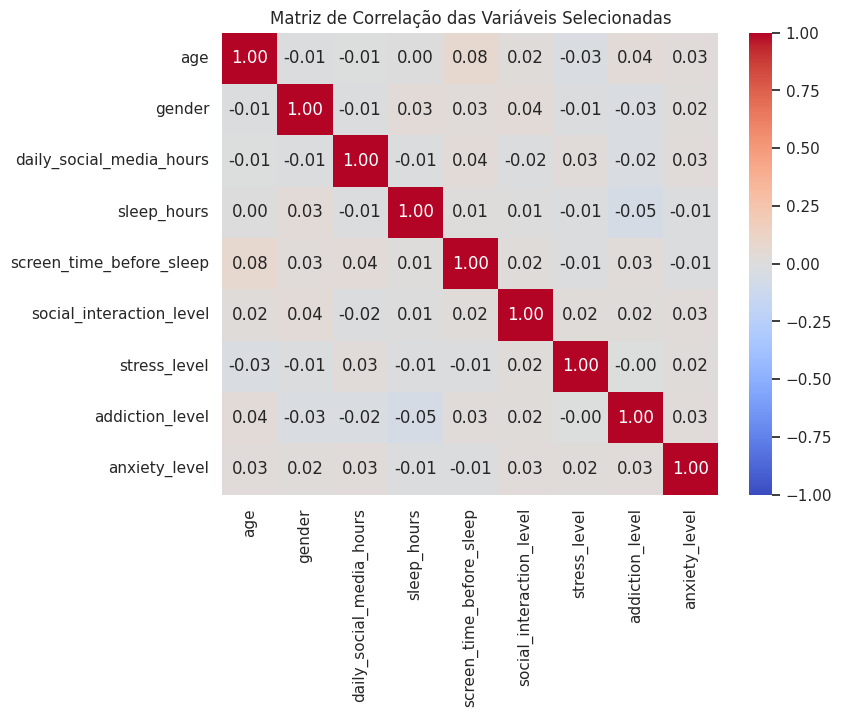

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Selecionadas")
plt.show()

Gráfico de dispersão entre a variável de maior correlação e o alvo:

## 5.1. Verificando outras correlações

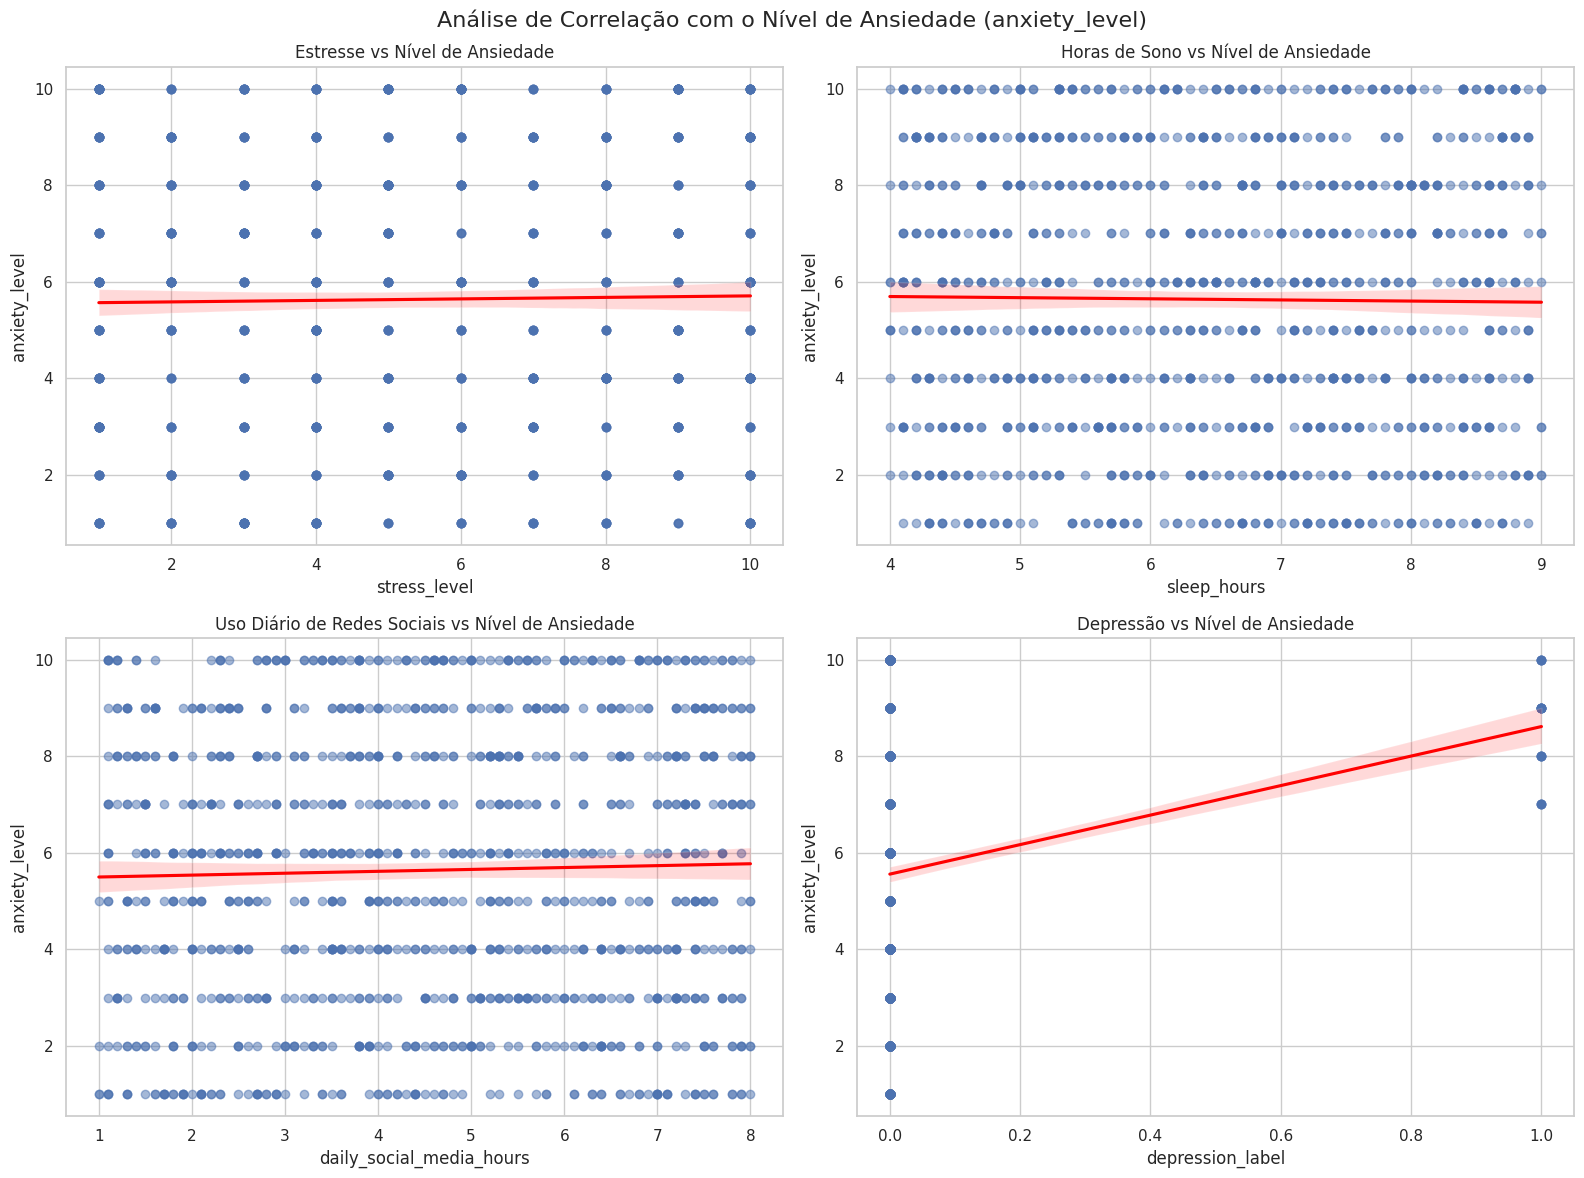

In [19]:
# Célula 8: Visualização de 4 correlações importantes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análise de Correlação com o Nível de Ansiedade (anxiety_level)', fontsize=16)

# 1. Ansiedade vs Estresse
sns.regplot(ax=axes[0, 0], data=df_silver, x='stress_level', y='anxiety_level', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0, 0].set_title('Estresse vs Nível de Ansiedade')

# 2. Horas de Sono vs Estresse
sns.regplot(ax=axes[0, 1], data=df_silver, x='sleep_hours', y='anxiety_level', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0, 1].set_title('Horas de Sono vs Nível de Ansiedade')

# 3. Horas Diárias em Redes Sociais vs Nível de Ansiedade
sns.regplot(ax=axes[1, 0], data=df_silver, x='daily_social_media_hours', y='anxiety_level', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1, 0].set_title('Uso Diário de Redes Sociais vs Nível de Ansiedade')

# 4. Atividade Física vs Nível de Ansiedade
sns.regplot(ax=axes[1, 1], data=df_silver, x='depression_label', y='anxiety_level', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1, 1].set_title('Depressão vs Nível de Ansiedade')

plt.tight_layout()
plt.show()

# 6. Feature Engineering: Validação da Variável-Alvo Composta

Antes de assumirmos a regra `(Estresse >= 7) OU (Ansiedade >= 7) OU (Depressão == 1)`, precisamos validar estatisticamente se essa união faz sentido. 
Vamos analisar a sobreposição (overlap) dessas condições e verificar se a nova classe gerada apresenta um ganho de correlação com os atributos preditores em relação às variáveis isoladas.

## 6.1. Análise de Sobreposição e Distribuição

Criando a variável temporariamente para análise:

In [20]:
df_severity = df_silver.copy()

In [21]:
df_severity['severity_score'] = (
    (df_severity['stress_level'] * 4) + 
    (df_severity['anxiety_level'] * 4) + 
    (df_severity['depression_label'] * 20)
)

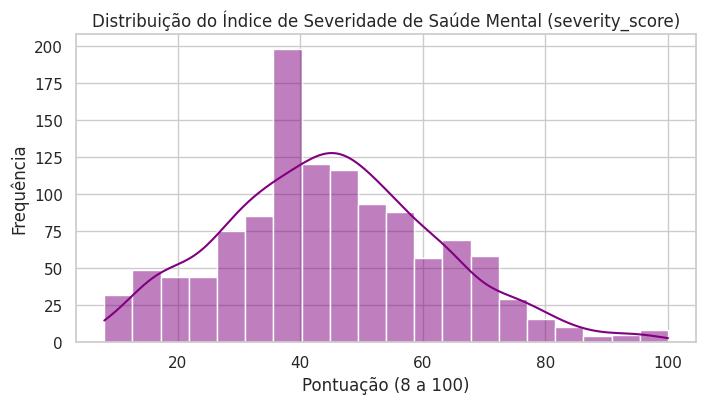

In [22]:
# Plotando a distribuição da nova variável para garantir que não há anomalias
plt.figure(figsize=(8, 4))
sns.histplot(df_severity['severity_score'], bins=20, kde=True, color='purple')
plt.title('Distribuição do Índice de Severidade de Saúde Mental (severity_score)')
plt.xlabel('Pontuação (8 a 100)')
plt.ylabel('Frequência')
plt.show()

# 7. Criação, Divisão e Exportação para Silve

In [23]:
target_col = 'depression_label'

# Dropamos o alvo E as variáveis colineares (estresse e ansiedade)
X = df_silver.drop(columns=[target_col, 'stress_level', 'anxiety_level'])
y = df_silver[target_col]

df_silver.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   int64  
 2   daily_social_media_hours  1200 non-null   float64
 3   sleep_hours               1200 non-null   float64
 4   screen_time_before_sleep  1200 non-null   float64
 5   academic_performance      1200 non-null   float64
 6   physical_activity         1200 non-null   float64
 7   social_interaction_level  1200 non-null   int64  
 8   stress_level              1200 non-null   int64  
 9   anxiety_level             1200 non-null   int64  
 10  addiction_level           1200 non-null   int64  
 11  depression_label          1200 non-null   int64  
 12  platform_usage_Instagram  1200 non-null   int64  
 13  platform_usage_TikTok     1200 non-null   int64  
dtypes: float64(5), int6

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("=== Distribuição ANTES do SMOTE (Apenas Treino) ===")
print(y_train.value_counts())

=== Distribuição ANTES do SMOTE (Apenas Treino) ===
depression_label
0    935
1     25
Name: count, dtype: int64


## 7.1. Aplicação do SMOTE:

In [25]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n=== Distribuição DEPOIS do SMOTE (Treino Balanceado) ===")
print(y_train_smote.value_counts())


=== Distribuição DEPOIS do SMOTE (Treino Balanceado) ===
depression_label
0    935
1    935
Name: count, dtype: int64


Construindo os novos Dataframes:

In [26]:
train_df = pd.concat([X_train_smote, y_train_smote], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print(f"\nTamanho Treino: {train_df.shape} | Proporção da Classe 1: {train_df['depression_label'].mean():.2f}")
print(f"Tamanho Teste:  {test_df.shape} | Proporção da Classe 1: {test_df['depression_label'].mean():.2f}")


Tamanho Treino: (1870, 12) | Proporção da Classe 1: 0.50
Tamanho Teste:  (240, 12) | Proporção da Classe 1: 0.03


Exportando para a Camada Silver

In [27]:
SILVER_PATH = '../data/silver'

os.makedirs(SILVER_PATH, exist_ok=True)

In [28]:
train_output = f'{SILVER_PATH}/train.csv'
test_output = f'{SILVER_PATH}/test.csv'

train_df.to_csv(train_output, index=False)
test_df.to_csv(test_output, index=False)

print(f"\nArquivos 'train.csv' e 'test.csv' salvos com sucesso na pasta '{SILVER_PATH}'.")
print("A camada Silver está pronta para ser consumida pelos experimentos do FLAML e MLJAR.")


Arquivos 'train.csv' e 'test.csv' salvos com sucesso na pasta '../data/silver'.
A camada Silver está pronta para ser consumida pelos experimentos do FLAML e MLJAR.
